<a href="https://colab.research.google.com/github/LordSurov/123/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Суров С
 ИУ5-84Б ЛАБ 6

In [ ]:
Variant<-18
set.seed(Variant+864)
K<-sample(c(4:8),1)
M<-sample(c(2:5),1)
N<-sample(c(2:6),1)
lambda<-runif(1)
mu<-runif(1)
nu<-runif(1)
p<-runif(1,0,0.5)
m1<-sample(c(1:3),1)
m2<-sample(c(1:3),1)
View(data.frame(K,M,N,lambda,mu,nu,p,m1,m2))

K,M,N,lambda,mu,nu,p,m1,m2
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
7,4,5,0.665381,0.4249381,0.8750494,0.1735299,2,1


In [ ]:
install.packages("simmer")
install.packages("simmer.plot")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("tidyr")
install.packages("knitr")
install.packages("igraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘igraph’, ‘visNetwork’, ‘DiagrammeR’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(simmer)        # Для имитационного моделирования
library(simmer.plot)   # Для визуализации simmer
library(ggplot2)       # Для графиков
library(dplyr)         # Для обработки данных
library(tidyr)         # Для трансформации данных
library(knitr)         # Для красивых таблиц
library(igraph)

Loading required package: ggplot2


Attaching package: ‘simmer.plot’


The following objects are masked from ‘package:simmer’:

    get_mon_arrivals, get_mon_attributes, get_mon_resources



Attaching package: ‘dplyr’


The following object is masked from ‘package:simmer’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘tidyr’


The following object is masked from ‘package:simmer’:

    separate



Attaching package: ‘igraph’


The following object is masked from ‘package:tidyr’:

    crossing


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




In [ ]:
# исходные данные
params_graph <- list(
  K = 7, M = 4, N = 5,
  lambda = 0.665381, mu = 0.4249381,
  nu = 0.8750494, p = 0.1735299,
  m1 = 2, m2 = 1
)

# Генерация всех состояний (i,j,k)
states <- list()
names_list <- c()
max_j <- params_graph$N + params_graph$m1
max_k <- params_graph$M + params_graph$m2

In [ ]:
for (i in 0:params_graph$K) {
  for (j in 0:max_j) {
    k <- params_graph$K - i - j
    if (k >= 0 && k <= max_k) {
      name <- sprintf("(%d,%d,%d)", i, j, k)
      states[[name]] <- c(i=i, j=j, k=k)
      names_list <- c(names_list, name)
    }
  }
}

n_states <- length(states)
cat("Найдено", n_states, "состояний (i=программисты, j=антивирусы, k=серверы)\n")

Найдено 33 состояний (i=программисты, j=антивирусы, k=серверы)


In [ ]:
# Построение списка переходов (ВЕКТОРЫ ДОЛЖНЫ БЫТЬ СИНХРОНИЗИРОВАНЫ)
edges_from <- c()
edges_to <- c()
edges_label <- c()
edges_color <- c()
edges_type <- c()

for (idx in 1:n_states) {
  state_name <- names_list[idx]
  s <- states[[state_name]]
  i <- s["i"]; j <- s["j"]; k <- s["k"]

  # Тип 1: Программист закончил → на антивирус (синий)
  if (i > 0 && j < max_j) {
    target <- sprintf("(%d,%d,%d)", i-1, j+1, k)
    if (target %in% names_list) {
      rate <- i * params_graph$lambda
      edges_from <- c(edges_from, state_name)
      edges_to <- c(edges_to, target)
      edges_label <- c(edges_label, sprintf("λ%d=%.2f", i, rate))
      edges_color <- c(edges_color, "blue")
      edges_type <- c(edges_type, "generation")
    }
  }

  # Тип 2: Вирус обнаружен → возврат к программисту (красный)
  if (j > 0) {
    busy_antiv <- min(j, params_graph$N)
    if (busy_antiv > 0) {
      target <- sprintf("(%d,%d,%d)", i+1, j-1, k)
      if (target %in% names_list) {
        rate <- busy_antiv * params_graph$nu * params_graph$p
        edges_from <- c(edges_from, state_name)
        edges_to <- c(edges_to, target)
        edges_label <- c(edges_label, sprintf("ν%dp=%.2f", busy_antiv, rate))
        edges_color <- c(edges_color, "red")
        edges_type <- c(edges_type, "rejection")
      }
    }
  }

  # Тип 3: Проверка пройдена → на сервер (зеленый)
  if (j > 0 && k < max_k) {
    busy_antiv <- min(j, params_graph$N)
    if (busy_antiv > 0) {
      target <- sprintf("(%d,%d,%d)", i, j-1, k+1)
      if (target %in% names_list) {
        rate <- busy_antiv * params_graph$nu * (1 - params_graph$p)
        edges_from <- c(edges_from, state_name)
        edges_to <- c(edges_to, target)
        edges_label <- c(edges_label, sprintf("ν%d(1-p)=%.2f", busy_antiv, rate))
        edges_color <- c(edges_color, "green3")
        edges_type <- c(edges_type, "to_server")
      }
    }
  }

  # Тип 4: Сервер завершил → новая программа (фиолетовый)
  if (k > 0) {
    busy_srv <- min(k, params_graph$M)
    if (busy_srv > 0) {
      target <- sprintf("(%d,%d,%d)", i+1, j, k-1)
      if (target %in% names_list) {
        rate <- busy_srv * params_graph$mu
        edges_from <- c(edges_from, state_name)
        edges_to <- c(edges_to, target)
        edges_label <- c(edges_label, sprintf("μ%d=%.2f", busy_srv, rate))
        edges_color <- c(edges_color, "purple")
        edges_type <- c(edges_type, "completion")
      }
    }
  }
}

In [ ]:
# Создание графа
edges_df <- data.frame(
  from = edges_from,
  to = edges_to,
  label = edges_label,
  color = edges_color,
  type = edges_type,
  stringsAsFactors = FALSE
)

g <- graph_from_data_frame(edges_df, directed = TRUE,
                           vertices = data.frame(name = unique(names_list)))

# Настройка вершин
V(g)$load <- sapply(V(g)$name, function(v) sum(states[[v]][c("j","k")]))
V(g)$size <- 15 + 2 * V(g)$load
V(g)$color <- sapply(V(g)$load, function(l) {
  ifelse(l==0, "lightgreen", ifelse(l<=2, "yellow", ifelse(l<=4, "orange", "coral")))
})

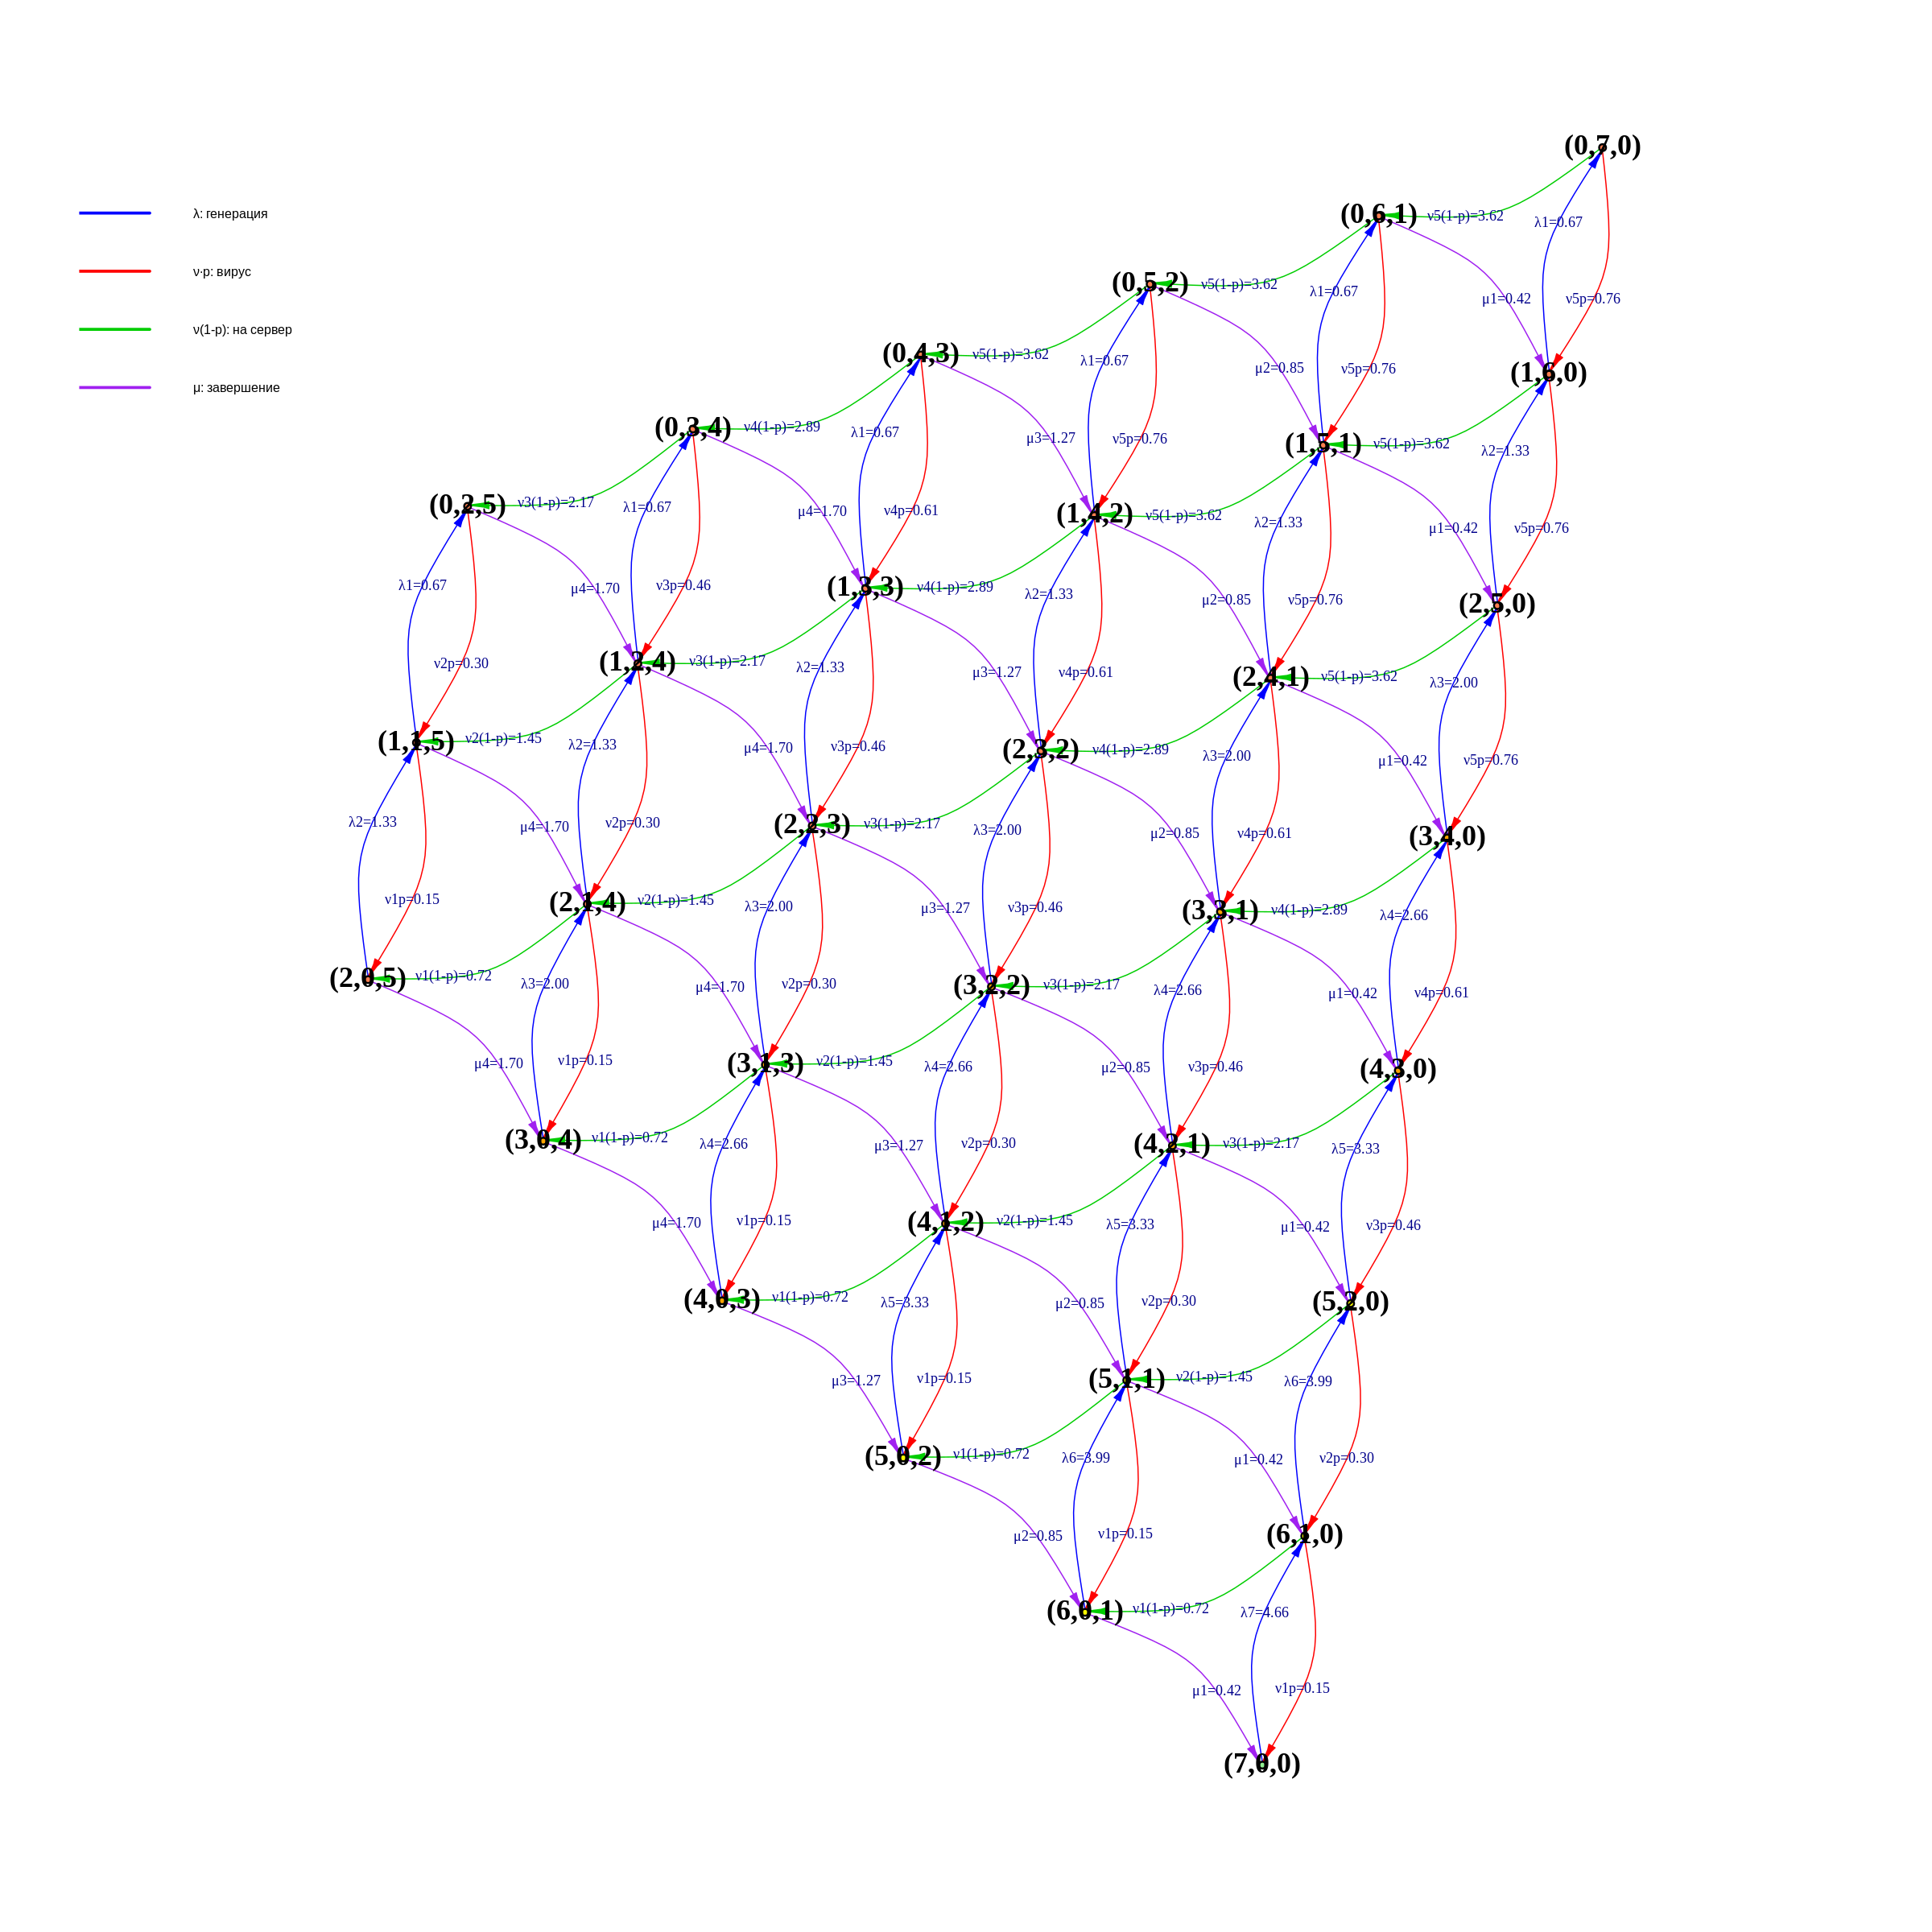

In [ ]:
options(repr.plot.width=20, repr.plot.height=20)
set.seed(123)


plot(g, layout=layout_kk,
     vertex.size=20,
     vertex.color=V(g)$color,
     vertex.frame.color="black",
     vertex.frame.width=2,

     vertex.label=V(g)$name,
     vertex.label.cex=1.8,
     vertex.label.color="black",
     vertex.label.font=2,

     # Ребра с сильной кривизной, чтобы текст был дальше от вершин
     edge.color=E(g)$color,
     edge.width=1.2,              # тонкие линии
     edge.arrow.size=0.25,        # маленькие стрелки
     edge.arrow.width=0.6,

     # Метки на ребрах - сдвинуты кривизной дальше от центра
     edge.label=E(g)$label,
     edge.label.cex=0.9,          # чуть меньше, чтобы точно влезать
     edge.label.color="darkblue",
     edge.curved=0.4,             # СИЛЬНАЯ кривизна - текст дальше от кружков

     margin=c(0.1, 0.1, 0.1, 0.1),
     main=NULL,
     rescale=FALSE)               # важно для сохранения масштаба

legend("topleft",
       inset=c(0.01, 0.01),
       legend=c("λ: генерация", "ν·p: вирус", "ν(1-p): на сервер", "μ: завершение"),
       col=c("blue", "red", "green3", "purple"),
       lty=1,
       lwd=3,
       cex=0.8,
       bg="white",
       bty="n",
       title=NA)

In [ ]:
options(repr.plot.width=16, repr.plot.height=12)

In [ ]:
params <- list(
  K = 7,           # Количество программистов (заявок в системе)
  M = 4,           # Количество основных серверов
  N = 5,           # Количество антивирусных компьютеров
  lambda = 0.665381,  # Интенсивность работы программистов
  mu = 0.4249381,     # Интенсивность работы серверов
  nu = 0.8750494,     # Интенсивность работы антивирусов
  p = 0.1735299,      # Вероятность обнаружения вируса
  m1 = 2,          # Очередь к антивирусам (макс. длина)
  m2 = 1           # Очередь к серверам (макс. длина)
)

cat(sprintf("K=%d программистов, M=%d серверов, N=%d антивирусов\n",
            params$K, params$M, params$N))
cat(sprintf("λ=%.4f, μ=%.4f, ν=%.4f, p=%.4f\n",
            params$lambda, params$mu, params$nu, params$p))
cat(sprintf("Очереди: m1=%d (к антивирусам), m2=%d (к серверам)\n",
            params$m1, params$m2))

K=7 программистов, M=4 серверов, N=5 антивирусов
λ=0.6654, μ=0.4249, ν=0.8750, p=0.1735
Очереди: m1=2 (к антивирусам), m2=1 (к серверам)


generate_states cоздает все возможные состояния системы (i,j,k) , где i  — число программистов, пишущих код, j  — число программ на антивирусной проверке (включая очередь), k  — число программ на серверах (включая очередь).

In [ ]:
generate_states <- function(K, M, N, m1, m2) {
  states <- list()
  idx <- 1

  # i - программисты пишут (0..K)
  # j - на антивирусах (0..N+m1)
  # k - на серверах (0..M+m2)
  # Условие: i + j + k = K

  max_j <- N + m1  # максимум на антивирусах (каналы + очередь)
  max_k <- M + m2  # максимум на серверах (каналы + очередь)

  for (i in 0:K) {
    for (j in 0:min(max_j, K - i)) {
      k <- K - i - j
      if (k >= 0 && k <= max_k) {
        states[[idx]] <- c(i = i, j = j, k = k,
                          name = sprintf("S_%d%d%d", i, j, k))
        idx <- idx + 1
      }
    }
  }

  return(do.call(rbind, states))
}

In [ ]:
states_df <- generate_states(params$K, params$M, params$N, params$m1, params$m2)
states_df <- as.data.frame(states_df)
states_df$i <- as.numeric(states_df$i)
states_df$j <- as.numeric(states_df$j)
states_df$k <- as.numeric(states_df$k)

cat(sprintf("Сгенерировано %d состояний системы\n", nrow(states_df)))
cat("Примеры состояний (i=прогр, j=антивирус, k=сервер):\n")
print(head(states_df[, c("i", "j", "k", "name")], 33))

Сгенерировано 33 состояний системы
Примеры состояний (i=прогр, j=антивирус, k=сервер):
   i j k  name
1  0 2 5 S_025
2  0 3 4 S_034
3  0 4 3 S_043
4  0 5 2 S_052
5  0 6 1 S_061
6  0 7 0 S_070
7  1 1 5 S_115
8  1 2 4 S_124
9  1 3 3 S_133
10 1 4 2 S_142
11 1 5 1 S_151
12 1 6 0 S_160
13 2 0 5 S_205
14 2 1 4 S_214
15 2 2 3 S_223
16 2 3 2 S_232
17 2 4 1 S_241
18 2 5 0 S_250
19 3 0 4 S_304
20 3 1 3 S_313
21 3 2 2 S_322
22 3 3 1 S_331
23 3 4 0 S_340
24 4 0 3 S_403
25 4 1 2 S_412
26 4 2 1 S_421
27 4 3 0 S_430
28 5 0 2 S_502
29 5 1 1 S_511
30 5 2 0 S_520
31 6 0 1 S_601
32 6 1 0 S_610
33 7 0 0 S_700


 build_transition_matrix cтроит матрицу инфинитезимальных характеристик (Q-матрицу) для марковского процесса. Определяет интенсивности переходов между состояниями: программист закончил писать → на антивирус, антивирус нашел вирус → назад к программисту, антивирус чист → на сервер, сервер закончил → к программисту

In [ ]:
# Построение матрицы инфинитезимальных характеристик

build_transition_matrix <- function(states, params) {
  n <- nrow(states)
  Q <- matrix(0, nrow = n, ncol = n)
  rownames(Q) <- states$name
  colnames(Q) <- states$name

  max_j <- params$N + params$m1  # макс на антивирусах
  max_k <- params$M + params$m2  # макс на серверах

  for (idx in 1:n) {
    i <- states$i[idx]
    j <- states$j[idx]
    k <- states$k[idx]

    # 1. Переход: программист закончил писать → на антивирус
    # Условие: должен быть свободный программист (i>0) и место на антивирусах (j < max_j)
    if (i > 0 && j < max_j) {
      new_i <- i - 1
      new_j <- j + 1
      new_k <- k
      target_name <- sprintf("S_%d%d%d", new_i, new_j, new_k)
      if (target_name %in% states$name) {
        rate <- i * params$lambda
        Q[idx, target_name] <- Q[idx, target_name] + rate
      }
    }

    # 2. Переход: антивирус нашел вирус → назад к программисту
    # Условие: есть программы на проверке (j>0), с вероятностью p
    # Занятые каналы: min(j, N)
    if (j > 0) {
      busy_antiviruses <- min(j, params$N)
      new_i <- i + 1
      new_j <- j - 1
      new_k <- k
      target_name <- sprintf("S_%d%d%d", new_i, new_j, new_k)
      if (target_name %in% states$name) {
        rate <- busy_antiviruses * params$nu * params$p
        Q[idx, target_name] <- Q[idx, target_name] + rate
      }
    }

    # 3. Переход: антивирус чист → на сервер
    # Условие: есть программы на проверке (j>0) и место на серверах (k < max_k), с вероятностью (1-p)
    if (j > 0 && k < max_k) {
      busy_antiviruses <- min(j, params$N)
      new_i <- i
      new_j <- j - 1
      new_k <- k + 1
      target_name <- sprintf("S_%d%d%d", new_i, new_j, new_k)
      if (target_name %in% states$name) {
        rate <- busy_antiviruses * params$nu * (1 - params$p)
        Q[idx, target_name] <- Q[idx, target_name] + rate
      }
    }

    # 4. Переход: сервер закончил → к программисту (новая программа)
    # Условие: есть программы на серверах (k>0)
    if (k > 0) {
      busy_servers <- min(k, params$M)
      new_i <- i + 1
      new_j <- j
      new_k <- k - 1
      target_name <- sprintf("S_%d%d%d", new_i, new_j, new_k)
      if (target_name %in% states$name) {
        rate <- busy_servers * params$mu
        Q[idx, target_name] <- Q[idx, target_name] + rate
      }
    }
  }

  # Диагональные элементы: сумма уходов из состояния со знаком минус
  for (idx in 1:n) {
    Q[idx, idx] <- -sum(Q[idx, ])
  }

  return(Q)
}

In [ ]:
Q_matrix <- build_transition_matrix(states_df, params)

cat(sprintf("Построена Q-матрица размером %dx%d\n", nrow(Q_matrix), ncol(Q_matrix)))

cat(" Полная матрица Q (округлено до 2 знаков)\n")
options(width = 210)
print(round(Q_matrix, 2))

Построена Q-матрица размером 33x33
 Полная матрица Q (округлено до 2 знаков)
      S_025 S_034 S_043 S_052 S_061 S_070 S_115 S_124 S_133 S_142 S_151 S_160 S_205 S_214 S_223 S_232 S_241 S_250 S_304 S_313 S_322 S_331 S_340 S_403 S_412 S_421 S_430 S_502 S_511 S_520 S_601 S_610 S_700
S_025 -2.00  0.00  0.00  0.00  0.00  0.00  0.30  1.70  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
S_034  2.17 -4.32  0.00  0.00  0.00  0.00  0.00  0.46  1.70  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
S_043  0.00  2.89 -4.78  0.00  0.00  0.00  0.00  0.00  0.61  1.27  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00
S_052  0.00  0.00  3.62 -5.23  0.00  0.00  0.00  0.00  0.00  0.76  0.85  0.00  0.00  0.00  0.00  0.00  0.00

Решает систему линейных алгебраических уравнений P⋅Q=0  с нормировкой ∑P=1  для нахождения финальных (стационарных) вероятностей всех состояний. Использует псевдообратную матрицу для решения СЛАУ.

In [ ]:
# Решение уравнений Колмогорова (стационарные вероятности)
solve_stationary <- function(Q) {
  n <- nrow(Q)
  # Система: P^T * Q = 0, sum(P) = 1
  # Заменяем последнее уравнение на условие нормировки
  A <- t(Q)
  A[n, ] <- 1  # последняя строка - сумма вероятностей = 1
  b <- c(rep(0, n-1), 1)

  # Решение методом наименьших квадратов (для численной устойчивости)
  P <- solve(A, b)
  names(P) <- colnames(Q)
  return(P)
}

In [ ]:
stationary_probs <- solve_stationary(Q_matrix)

cat(sprintf("Сумма вероятностей: %.10f (должна быть 1.0)\n", sum(stationary_probs)))

states_df$prob_exact <- stationary_probs[states_df$name]
options(width = 90)
for (nm in names(stationary_probs)) {
  cat(nm, "=", round(stationary_probs[nm], 10), "\n")
}

Сумма вероятностей: 1.0000000000 (должна быть 1.0)
S_025 = 0.04100368 
S_034 = 0.01878749 
S_043 = 0.0103704 
S_052 = 0.003589516 
S_061 = 0.0008364019 
S_070 = 9.78017e-05 
S_115 = 0.0622008 
S_124 = 0.0770302 
S_133 = 0.05491448 
S_142 = 0.02364243 
S_151 = 0.005502459 
S_160 = 0.0006431004 
S_205 = 0.02456397 
S_214 = 0.08987315 
S_223 = 0.1082669 
S_232 = 0.06217113 
S_241 = 0.01808206 
S_250 = 0.002113042 
S_304 = 0.03270707 
S_313 = 0.09054486 
S_322 = 0.08121027 
S_331 = 0.03162393 
S_340 = 0.004624202 
S_403 = 0.02716284 
S_412 = 0.05196224 
S_421 = 0.03095372 
S_430 = 0.006059736 
S_502 = 0.01294512 
S_511 = 0.01597208 
S_520 = 0.004745834 
S_601 = 0.003375198 
S_610 = 0.002049137 
S_700 = 0.0003747382 


In [ ]:
# Расчет характеристик эффективности
calculate_exact_metrics <- function(states, params) {
  # Среднее число заявок в системе (в обработке: j на антивирусах + k на серверах)
  L_sist <- sum((states$j + states$k) * states$prob_exact)

  # Среднее число занятых программистов (работающих)
  busy_progers <- sum(states$i * states$prob_exact)

  # Средняя интенсивность входного потока (программы поступают к антивирусам)
  Lambda <- (params$K - L_sist) * params$lambda

  # Абсолютная пропускная способность (полезный выход: серверы обрабатывают)
  # Это интенсивность, с которой программы покидают серверы (успешно выполнены)
  lambda_abs <- 0
  for (idx in 1:nrow(states)) {
    k <- states$k[idx]
    if (k > 0) {
      busy_servers <- min(k, params$M)
      rate_out <- busy_servers * params$mu  # интенсивность ухода с серверов
      lambda_abs <- lambda_abs + rate_out * states$prob_exact[idx]
    }
  }

  # Среднее время пребывания заявки в системе (формула Литтла)
  T_sist <- L_sist / Lambda

  return(list(
    L_sist = L_sist,
    Lambda = Lambda,
    lambda_abs = lambda_abs,
    T_sist = T_sist,
    busy_progers = busy_progers
  ))
}

In [ ]:
metrics_exact <- calculate_exact_metrics(states_df, params)

cat("ТОЧНЫЙ МЕТОД (решение уравнений Колмогорова)\n\n")

cat(sprintf("Среднее число заявок в системе L: %.4f\n", metrics_exact$L_sist))

cat(sprintf("Среднее число занятых программистов: %.4f из %d\n",
            metrics_exact$busy_progers, params$K))
cat(sprintf("Интенсивность входного потока Λ: %.4f\n", metrics_exact$Lambda))

cat(sprintf("Абсолютная пропускная способность λ': %.4f\n", metrics_exact$lambda_abs))

cat(sprintf("Среднее время пребывания T: %.4f\n", metrics_exact$T_sist))

ТОЧНЫЙ МЕТОД (решение уравнений Колмогорова)

Среднее число заявок в системе L: 4.7758
Среднее число занятых программистов: 2.2242 из 7
Интенсивность входного потока Λ: 1.4800
Абсолютная пропускная способность λ': 1.2051
Среднее время пребывания T: 3.2269


In [ ]:
# Метод агрегирования — расчет параметров связи μ(u)

calculate_mu_link <- function(u, params) {
  if (u == 0) return(0)
  max_states <- min(u, params$M) + 1

  # Индекс n - число заявок на серверах
  # Переход n -> n+1: интенсивность nu_n (поступление с антивирусов)
  # Переход n -> n-1: интенсивность mu_n (уход с серверов)

  transitions <- matrix(0, nrow = max_states, ncol = max_states)

  for (n in 0:(max_states-1)) {
    # Интенсивность поступления на серверы (из антивирусов)
    # Число на антивирусах = u - n, но не более N могут проверяться
    on_antiviruses <- u - n
    busy_antiviruses <- min(on_antiviruses, params$N)
    # Только (1-p) доля идет на серверы
    lambda_n <- busy_antiviruses * params$nu * (1 - params$p)

    # Интенсивность ухода с серверов
    busy_servers <- min(n, params$M)
    mu_n <- busy_servers * params$mu

    if (n < max_states - 1) {
      transitions[n+1, n+2] <- lambda_n  # рождение (поступление на сервер)
    }
    if (n > 0) {
      transitions[n+1, n] <- mu_n        # гибель (уход с сервера)
    }
  }

  # Диагональ
  for (i in 1:max_states) {
    transitions[i, i] <- -sum(transitions[i, ])
  }

  # Решение для стационарных вероятностей подсистемы
  A <- t(transitions)
  A[max_states, ] <- 1
  b <- c(rep(0, max_states-1), 1)
  pi <- solve(A, b)

  # mu(u) = сумма по n (mu_n * pi_n) = интенсивность выхода из подсистемы
  mu_u <- 0
  for (n in 0:(max_states-1)) {
    busy_servers <- min(n, params$M)
    mu_n <- busy_servers * params$mu
    mu_u <- mu_u + mu_n * pi[n+1]
  }

  return(mu_u)
}

In [ ]:
# Расчет параметров связи для u = 1..K
mu_links <- sapply(1:params$K, function(u) calculate_mu_link(u, params))

cat("Параметры связи μ(u) для u=1..K:\n")
for (u in 1:params$K) {
  cat(sprintf("u=%d: μ(%d) = %.4f\n", u, u, mu_links[u]))
}

Параметры связи μ(u) для u=1..K:
u=1: μ(1) = 0.2677
u=2: μ(2) = 0.5353
u=3: μ(3) = 0.8030
u=4: μ(4) = 1.0707
u=5: μ(5) = 1.2518
u=6: μ(6) = 1.3636
u=7: μ(7) = 1.4307


In [ ]:
# Расчет характеристик методом параметров связи

calculate_aggregation_metrics <- function(params, mu_links) {
  K <- params$K
  lambda <- params$lambda

  # Модель рождения-гибели для замкнутой системы
  # Состояния: k = 0..K (число заявок в агрегированном узле)
  # Переход k -> k+1: интенсивность (K-k)*lambda (программисты генерируют)
  # Переход k -> k-1: интенсивность mu_links[k] (агрегированный узел обрабатывает)

  # Расчет нормировочной константы (формула 2.1 из лекции)
  # P_0 = 1 / (1 + sum(prod))

  terms <- c(1)  # для k=0
  for (k in 1:K) {
    # Числитель: K! / (K-k)! * lambda^k
    # Знаменатель: произведение mu_links[1..k]
    numerator <- prod((K:(K-k+1))) * (lambda^k)
    denominator <- prod(mu_links[1:k])
    term <- numerator / denominator
    terms <- c(terms, term)
  }

  P_0 <- 1 / sum(terms)
  P_k <- terms * P_0

  # Характеристики
  L_sist <- sum((0:K) * P_k)  # среднее число в агрегированном узле
  Lambda <- (K - L_sist) * lambda
  mu_avg <- sum(mu_links * P_k[2:(K+1)])  # средняя интенсивность обслуживания

  # Абсолютная пропускная способность
  lambda_abs <- mu_avg  # в стационаре: вход = выход

  # Время пребывания (формула Литтла)
  T_sist <- L_sist / Lambda

  return(list(
    L_sist = L_sist,
    Lambda = Lambda,
    lambda_abs = lambda_abs,
    T_sist = T_sist,
    P_k = P_k,
    mu_avg = mu_avg
  ))
}

In [ ]:
metrics_agg <- calculate_aggregation_metrics(params, mu_links)

cat("МЕТОД ПАРАМЕТРОВ СВЯЗИ (агрегирование)\n\n")
cat(sprintf("Среднее число заявок в системе L: %.4f\n", metrics_agg$L_sist))
cat(sprintf("Интенсивность входного потока Λ: %.4f\n", metrics_agg$Lambda))
cat(sprintf("Абсолютная пропускная способность λ': %.4f\n", metrics_agg$lambda_abs))
cat(sprintf("Среднее время пребывания T: %.4f\n", metrics_agg$T_sist))
cat(sprintf("Средняя интенсивность обслуживания μ_avg: %.4f\n", metrics_agg$mu_avg))

МЕТОД ПАРАМЕТРОВ СВЯЗИ (агрегирование)

Среднее число заявок в системе L: 5.1582
Интенсивность входного потока Λ: 1.2255
Абсолютная пропускная способность λ': 1.2255
Среднее время пребывания T: 4.2089
Средняя интенсивность обслуживания μ_avg: 1.2255


In [ ]:
# Имитационное моделирование

run_simulation_fixed <- function(params, simulation_time = 20000, warmup = 5000) {

  programmer_cycle <- trajectory("Programmer_Cycle") %>%
    # Шаг 1: Пишем код (отсюда начинаем отсчет для rollback)
    timeout(function() rexp(1, params$lambda)) %>%

    # Шаг 2: Антивирус
    seize("antivirus", 1) %>%
    timeout(function() rexp(1, params$nu)) %>%
    release("antivirus", 1) %>%

    # Шаг 5: Ветвление (после 4 шагов от начала)
    branch(
      function() sample(c(1, 2), 1, prob = c(params$p, 1 - params$p)),
      continue = c(FALSE, FALSE),

      # Ветка 1: Вирус - возврат на 4 шага назад (к timeout(lambda))
      # Текущая позиция: после release(antivirus), внутри branch
      # 1 шаг назад: release(antivirus)
      # 2: timeout(nu)
      # 3: seize(antivirus)
      # 4: timeout(lambda) <- сюда
      trajectory("Virus_Return") %>%
        rollback(target = 4),

      # Ветка 2: Чисто - на сервер и возврат на 7 шагов назад (к timeout(lambda))
      # Текущая позиция: после release(server)
      # 1: release(server)
      # 2: timeout(mu)
      # 3: seize(server)
      # 4: release(antivirus) (выход из ветки, возврат к основной)
      # 5: timeout(nu)
      # 6: seize(antivirus)
      # 7: timeout(lambda) <- сюда
      trajectory("Success_Path") %>%
        seize("server", 1) %>%
        timeout(function() rexp(1, params$mu)) %>%
        release("server", 1) %>%
        rollback(target = 7)
    )

  # Инициализация среды
  env <- simmer("Closed_System") %>%
    add_resource("antivirus", params$N, params$m1) %>%
    add_resource("server", params$M, params$m2)

  # Добавляем K программистов
  for (i in 1:params$K) {
    env <- add_generator(env, paste0("prog_", i), programmer_cycle,
                         function() c(0, Inf), mon = 2)
  }

  # Запуск
  env %>% run(until = simulation_time + warmup)

  # Сбор данных (после разогрева)
  resources <- get_mon_resources(env) %>%
    filter(time > warmup, time <= simulation_time + warmup)

  # Расчет L
  res_stats <- resources %>%
    group_by(resource) %>%
    summarise(avg_in_system = mean(server + queue, na.rm = TRUE))

  L_sist <- sum(res_stats$avg_in_system)

  # Абсолютная пропускная способность (освобождения серверов)
  server_data <- resources %>% filter(resource == "server")
  releases <- server_data %>%
    mutate(change = server - dplyr::lag(server, default = first(server))) %>%
    filter(change < 0) %>%
    nrow()

  lambda_abs <- releases / simulation_time

  # Время пребывания через Литтла
  T_sist <- if (lambda_abs > 0 && !is.na(lambda_abs)) L_sist / lambda_abs else NA
  Lambda <- (params$K - L_sist) * params$lambda

  return(list(
    L_sist = L_sist,
    Lambda = Lambda,
    lambda_abs = lambda_abs,
    T_sist = T_sist,
    res_stats = res_stats,
    resources = resources
  ))
}

In [ ]:
# Запуск моделирования
set.seed(42)
metrics_sim <- run_simulation_fixed(params, simulation_time = 20000, warmup = 5000)

cat("ИМИТАЦИОННОЕ МОДЕЛИРОВАНИЕ\n\n")
cat(sprintf("Среднее число заявок в системе L: %.4f\n", metrics_sim$L_sist))
cat(sprintf("  - на антивирусах: %.4f\n", metrics_sim$res_stats$avg_in_system[1]))
cat(sprintf("  - на серверах: %.4f\n", metrics_sim$res_stats$avg_in_system[2]))
cat(sprintf("Интенсивность входного потока Λ: %.4f\n", metrics_sim$Lambda))
cat(sprintf("Абсолютная пропускная способность λ': %.4f\n", metrics_sim$lambda_abs))
cat(sprintf("Среднее время пребывания T: %.4f\n", metrics_sim$T_sist))

ИМИТАЦИОННОЕ МОДЕЛИРОВАНИЕ

Среднее число заявок в системе L: 5.0015
  - на антивирусах: 1.9774
  - на серверах: 3.0241
Интенсивность входного потока Λ: 1.3298
Абсолютная пропускная способность λ': 1.1071
Среднее время пребывания T: 4.5177


In [ ]:
# Метод укрупнения состояний (горизонтальное)

horizontal_aggregation <- function(states_df, params) {
  # Горизонтальное укрупнение: объединяем по сумме j+k (число заявок в обработке)
  # Макросостояния W_u, где u = j+k (от 0 до K)

  states_df$u <- states_df$j + states_df$k  # суммарное число в обработке

  # Группировка по u
  macro_probs <- aggregate(prob_exact ~ u, data = states_df, sum)
  names(macro_probs) <- c("u", "prob_macro")

  # Расчет характеристик для макросостояний
  L_sist_macro <- sum(macro_probs$u * macro_probs$prob_macro)

  # Для горизонтального укрупнения строим упрощенную модель:
  # Переходы u -> u+1: интенсивность (K-u)*lambda (поступление)
  # Переходы u -> u-1: интенсивность зависит от структуры, но приближенно

  # Построим Q-матрицу для макропроцесса (u = 0..K)
  K <- params$K
  Q_macro <- matrix(0, nrow = K+1, ncol = K+1)

  for (u in 0:K) {
    # Уход из u: обработка (сложная функция от u, приближаем)
    if (u > 0) {
      # Средняя интенсивность обработки при u заявках в системе
      # Это взвешенная сумма интенсивностей выхода из состояний с данным u
      subset <- states_df[states_df$u == u, ]
      rate_out <- 0
      for (idx in 1:nrow(subset)) {
        i <- subset$i[idx]
        j <- subset$j[idx]
        k <- subset$k[idx]
        prob <- subset$prob_exact[idx]

        # Интенсивность ухода из этого микросостояния
        # Вирусные возвращаются (не уменьшают u), чистые уходят на серверы (u не меняется сразу),
        # но с серверов уходят (u уменьшается)
        busy_servers <- min(k, params$M)
        rate_out <- rate_out + busy_servers * params$mu * prob
      }
      if (u < K) Q_macro[u+1, u+2] <- (K-u)*params$lambda  # поступление
      if (u > 0) Q_macro[u+1, u] <- rate_out / sum(subset$prob_exact)  # уход (усредненный)
    } else {
      if (u < K) Q_macro[u+1, u+2] <- K*params$lambda
    }
  }

  # Диагональ
  for (i in 1:(K+1)) {
    Q_macro[i, i] <- -sum(Q_macro[i, ])
  }

  # Решение
  A <- t(Q_macro)
  A[K+1, ] <- 1
  b <- c(rep(0, K), 1)
  P_macro_calc <- solve(A, b)

  cat("Горизонтальное укрупнение (макросостояния по u=j+k):\n")
  cat("u (число в обработке) | Точная вероятность | Приближенная\n")
  for (u in 0:K) {
    exact_prob <- sum(states_df$prob_exact[states_df$u == u])
    approx_prob <- P_macro_calc[u+1]
    cat(sprintf("%d | %.6f | %.6f | ошибка: %.2f%%\n",
                u, exact_prob, approx_prob, abs(exact_prob-approx_prob)/exact_prob*100))
  }

  return(list(
    macro_probs = macro_probs,
    L_sist = L_sist_macro,
    P_macro = P_macro_calc
  ))
}

horiz_result <- horizontal_aggregation(states_df, params)

Горизонтальное укрупнение (макросостояния по u=j+k):
u (число в обработке) | Точная вероятность | Приближенная
0 | 0.000375 | 0.000140 | ошибка: 62.58%
1 | 0.005424 | 0.002470 | ошибка: 54.46%
2 | 0.033663 | 0.018663 | ошибка: 44.56%
3 | 0.116139 | 0.078429 | ошибка: 32.47%
4 | 0.240710 | 0.198226 | ошибка: 17.65%
5 | 0.305070 | 0.307113 | ошибка: 0.67%
6 | 0.223933 | 0.278096 | ошибка: 24.19%
7 | 0.074685 | 0.116863 | ошибка: 56.47%


In [ ]:
# Метод укрупнения состояний (вертикальное)

vertical_aggregation <- function(states_df, params) {
  # Вертикальное укрупнение: объединяем по j (число на антивирусах)
  # Макросостояния V_j, где j = 0..(N+m1)

  states_df$j <- as.numeric(states_df$j)

  # Группировка по j
  macro_probs_j <- aggregate(prob_exact ~ j, data = states_df, sum)
  names(macro_probs_j) <- c("j", "prob_macro")

  cat("Вертикальное укрупнение (макросостояния по j - число на антивирусах):\n")
  cat("j (антивирусы) | Точная вероятность\n")
  for (idx in 1:nrow(macro_probs_j)) {
    j <- macro_probs_j$j[idx]
    prob <- macro_probs_j$prob_macro[idx]
    cat(sprintf("%d | %.6f\n", j, prob))
  }

  # Расчет среднего числа на антивирусах и серверах по макросостояниям
  avg_j <- sum(states_df$j * states_df$prob_exact)
  avg_k <- sum(states_df$k * states_df$prob_exact)

  cat(sprintf("\nСреднее число на антивирусах (по вертикали): %.4f\n", avg_j))
  cat(sprintf("Среднее число на серверах (по разности): %.4f\n", avg_k))

  # Для квазиэквивалентного укрупнения можно построить упрощенную модель
  # с исправленными интенсивностями (как в лекции)

  return(list(
    macro_probs_j = macro_probs_j,
    avg_j = avg_j,
    avg_k = avg_k
  ))
}

vert_result <- vertical_aggregation(states_df, params)

Вертикальное укрупнение (макросостояния по j - число на антивирусах):
j (антивирусы) | Точная вероятность
0 | 0.101129
1 | 0.312602
2 | 0.343211
3 | 0.173557
4 | 0.056719
5 | 0.011205
6 | 0.001480
7 | 0.000098

Среднее число на антивирусах (по вертикали): 1.8122
Среднее число на серверах (по разности): 2.9636


In [ ]:
# Исследование влияния длин очередей m1 и m2

research_queues <- function(params, m1_range = 0:5, m2_range = 0:3) {
  results <- expand.grid(m1 = m1_range, m2 = m2_range)
  results$L_sist <- NA
  results$lambda_abs <- NA
  results$T_sist <- NA

  for (idx in 1:nrow(results)) {
    m1 <- results$m1[idx]
    m2 <- results$m2[idx]

    # Модифицируем параметры
    params_temp <- params
    params_temp$m1 <- m1
    params_temp$m2 <- m2

    # Пересчет методом агрегирования (быстрее точного)
    mu_links_temp <- sapply(1:params_temp$K, function(u) {
      # Упрощенный расчет mu(u) с новыми очередями
      max_j <- params_temp$N + m1
      max_k <- params_temp$M + m2
      # ... (упрощенная версия calculate_mu_link)
      # Для экономии времени используем приближение
      return(calculate_mu_link(u, params_temp))
    })

    metrics_temp <- calculate_aggregation_metrics(params_temp, mu_links_temp)

    results$L_sist[idx] <- metrics_temp$L_sist
    results$lambda_abs[idx] <- metrics_temp$lambda_abs
    results$T_sist[idx] <- metrics_temp$T_sist
  }

  return(results)
}



In [ ]:
# Запуск исследования (может занять время)
queue_research <- research_queues(params, m1_range = 0:4, m2_range = 0:3)

cat("=== ИССЛЕДОВАНИЕ ВЛИЯНИЯ ОЧЕРЕДЕЙ ===\n")
print(queue_research)

# Поиск оптимума: минимальное T при lambda_abs >= 90% от макс
max_lambda <- max(queue_research$lambda_abs)
threshold <- 0.9 * max_lambda
feasible <- queue_research[queue_research$lambda_abs >= threshold, ]
optimal <- feasible[which.min(feasible$T_sist), ]

cat(sprintf("\nОптимальные значения:\n"))
cat(sprintf("m1 = %d, m2 = %d\n", optimal$m1, optimal$m2))
cat(sprintf("T_sist = %.4f, lambda_abs = %.4f (%.1f%% от максимума)\n",
            optimal$T_sist, optimal$lambda_abs,
            optimal$lambda_abs/max_lambda*100))

=== ИССЛЕДОВАНИЕ ВЛИЯНИЯ ОЧЕРЕДЕЙ ===
   m1 m2   L_sist lambda_abs   T_sist
1   0  0 5.158156   1.225528 4.208927
2   1  0 5.158156   1.225528 4.208927
3   2  0 5.158156   1.225528 4.208927
4   3  0 5.158156   1.225528 4.208927
5   4  0 5.158156   1.225528 4.208927
6   0  1 5.158156   1.225528 4.208927
7   1  1 5.158156   1.225528 4.208927
8   2  1 5.158156   1.225528 4.208927
9   3  1 5.158156   1.225528 4.208927
10  4  1 5.158156   1.225528 4.208927
11  0  2 5.158156   1.225528 4.208927
12  1  2 5.158156   1.225528 4.208927
13  2  2 5.158156   1.225528 4.208927
14  3  2 5.158156   1.225528 4.208927
15  4  2 5.158156   1.225528 4.208927
16  0  3 5.158156   1.225528 4.208927
17  1  3 5.158156   1.225528 4.208927
18  2  3 5.158156   1.225528 4.208927
19  3  3 5.158156   1.225528 4.208927
20  4  3 5.158156   1.225528 4.208927

Оптимальные значения:
m1 = 0, m2 = 0
T_sist = 4.2089, lambda_abs = 1.2255 (100.0% от максимума)


In [ ]:
# Сравнение результатов всех методов

compare_methods <- function(exact, agg, sim) {
  comparison <- data.frame(
    Метод = c("Точный (Колмогоров)", "Агрегирование", "Имитационное (simmer)"),
    L_sist = c(exact$L_sist, agg$L_sist, sim$L_sist),
    Lambda = c(exact$Lambda, agg$Lambda, sim$Lambda),
    lambda_abs = c(exact$lambda_abs, agg$lambda_abs, sim$lambda_abs),
    T_sist = c(exact$T_sist, agg$T_sist, sim$T_sist)
  )

  # Добавляем относительные ошибки
  comparison$Ошибка_L <- abs(comparison$L_sist - exact$L_sist) / exact$L_sist * 100
  comparison$Ошибка_T <- abs(comparison$T_sist - exact$T_sist) / exact$T_sist * 100

  cat("=== СРАВНЕНИЕ МЕТОДОВ ===\n")
  print(comparison, row.names = FALSE, digits = 4)

  return(comparison)
}



In [ ]:
final_comparison <- compare_methods(metrics_exact, metrics_agg, metrics_sim)

kable(final_comparison, digits = 4, format = "markdown")

=== СРАВНЕНИЕ МЕТОДОВ ===
                 Метод L_sist Lambda lambda_abs T_sist Ошибка_L Ошибка_T
   Точный (Колмогоров)  4.776  1.480      1.205  3.227    0.000     0.00
         Агрегирование  5.158  1.226      1.226  4.209    8.007    30.43
 Имитационное (simmer)  5.002  1.330      1.107  4.518    4.727    40.00




|Метод                 | L_sist| Lambda| lambda_abs| T_sist| Ошибка_L| Ошибка_T|
|:---------------------|------:|------:|----------:|------:|--------:|--------:|
|Точный (Колмогоров)   | 4.7758| 1.4800|     1.2051| 3.2269|   0.0000|   0.0000|
|Агрегирование         | 5.1582| 1.2255|     1.2255| 4.2089|   8.0071|  30.4313|
|Имитационное (simmer) | 5.0015| 1.3298|     1.1071| 4.5177|   4.7271|  39.9990|